In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report
from sklearn.decomposition import PCA

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving adult.csv to adult.csv


In [ ]:
column_names=[
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

In [ ]:
data = pd.read_csv('adult.csv', header=None, names=column_names)

data = data.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
data.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
data.replace('?', np.nan, inplace=True)
data.dropna(inplace=True)

In [ ]:
categorical_cols= data.select_dtypes(include=['object']).columns.tolist()
target_col='income'
categorical_cols.remove(target_col)

label_encoders={}
for col in categorical_cols:
    le=LabelEncoder()
    data[col]=le.fit_transform(data[col])
    label_encoders[col]=le

target_encoder=LabelEncoder()
data[target_col]= target_encoder.fit_transform(data[target_col])

print("Unique vals in income col after encoding:", data[target_col].unique())

Unique vals in income col after encoding: [0 1]


In [ ]:
numerical_cols= [col for col in data.columns if col not in categorical_cols + [target_col]]
scaler=StandardScaler()
data[numerical_cols]=scaler.fit_transform(data[numerical_cols])

In [ ]:
X=data.drop(target_col, axis=1)
y=data[target_col]

print("Target col type:", y.dtype)
print("Target unique vals:", np.unique(y))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Target col type: int64
Target unique vals: [0 1]


In [ ]:
kernels=['linear', 'poly', 'rbf']
results={}

for kernel in kernels:
    print(f"\nTraining SVM with {kernel} kernel")
    svm=SVC(kernel=kernel)
    svm.fit(X_train, y_train)
    y_pred=svm.predict(X_test)

    acc=accuracy_score(y_test, y_pred)
    f1=f1_score(y_test, y_pred)
    cm=confusion_matrix(y_test, y_pred)
    report=classification_report(y_test, y_pred)

    results[kernel]={'accuracy': acc, 'f1_score': f1, 'confusion_matrix': cm}

    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Confusion Matrix:\n{cm}")
    print("\nClassification Report:\n", report)


Training SVM with linear kernel
Accuracy: 0.8100
F1 Score: 0.4511
Confusion Matrix:
[[4416  115]
 [1031  471]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.97      0.89      4531
           1       0.80      0.31      0.45      1502

    accuracy                           0.81      6033
   macro avg       0.81      0.64      0.67      6033
weighted avg       0.81      0.81      0.78      6033


Training SVM with poly kernel
Accuracy: 0.8139
F1 Score: 0.4588
Confusion Matrix:
[[4434   97]
 [1026  476]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.98      0.89      4531
           1       0.83      0.32      0.46      1502

    accuracy                           0.81      6033
   macro avg       0.82      0.65      0.67      6033
weighted avg       0.82      0.81      0.78      6033


Training SVM with rbf kernel
Accuracy: 0.8039
F1 Score: 0.4016
Confusion 

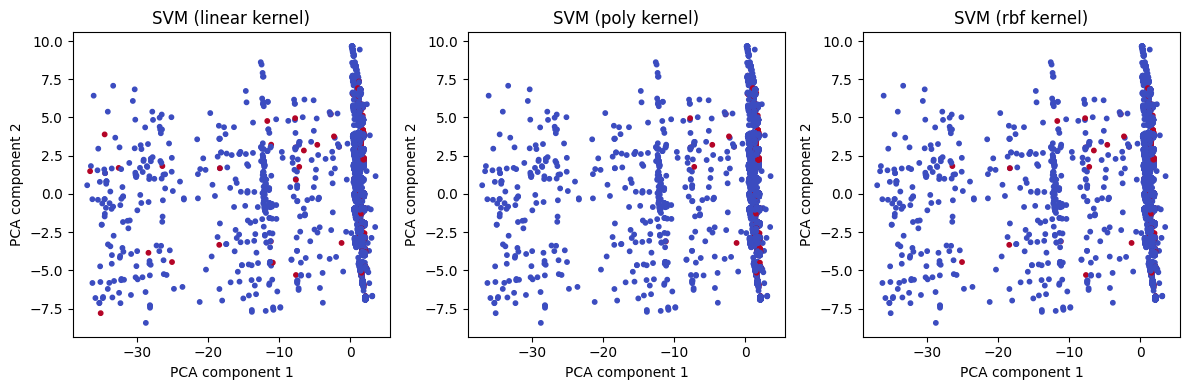

In [ ]:
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_test)

plt.figure(figsize=(12, 4))
for i, kernel in enumerate(kernels):
    svm=SVC(kernel=kernel)
    svm.fit(X_train, y_train)
    y_pred=svm.predict(X_test)

    plt.subplot(1, 3, i+1)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred, cmap='coolwarm', s=10)
    plt.title(f'SVM ({kernel} kernel)')
    plt.xlabel('PCA component 1')
    plt.ylabel('PCA component 2')

plt.tight_layout()
plt.show()

In [ ]:
print("Final Summary:")
for k, v in results.items():
    print(f"\nKernel: {k}")
    print(f"Accuracy: {v['accuracy']:.4f}")
    print(f"F1 Score: {v['f1_score']:.4f}")

Final Summary:

Kernel: linear
Accuracy: 0.8100
F1 Score: 0.4511

Kernel: poly
Accuracy: 0.8139
F1 Score: 0.4588

Kernel: rbf
Accuracy: 0.8039
F1 Score: 0.4016
